### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("WF_CPCV_PS_126")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WF_CPCV_PS_126.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [3]:
from wf_cpcv_search import load_nested_config
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench

In [4]:
log_print("median(ASR) - median(MDD) + median(SKEW)", section='Ojective', echo=False)

In [5]:
search_space = {'nondomin__min_n_assets': {'low': 10, 'high': 25, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.2},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.2},
 'extremes__k': {'low': 0.2, 'high': 0.6, 'step': 0.2},
 'nondomin__fitness_measures': [
    "mean-variance",
    "mean-variance-cvar",
    "mean-variance-avgdd",
    "mean-mad",
    "mean-mad-avgdd",
    "mean-mad-cvar",],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

2160

In [ ]:
fold_results = nested_adaptive_search(X,
                                      test_size=126,
                                      train_size=725+126,  # outer train size = max(inner_ts + test_size)
                                      space=search_space,
                                      n_test_folds=2,
                                      n_jobs=8,
                                      cv_n_jobs=4,
                                      n_trials=1200,
                                      patience=100,
                                      verbose=True,
                                      outer_purged_size=1,
                                      outer_reduce_test=False,)

  0%|          | 0/1200 [00:00<?, ?it/s]

Fold 0: inner_score=0.5524 | test_ann=0.1340 | test_days=126


  0%|          | 0/1200 [00:00<?, ?it/s]

Fold 1: inner_score=1.0665 | test_ann=0.1893 | test_days=126


  0%|          | 0/1200 [00:00<?, ?it/s]

...

  0%|          | 0/1200 [00:00<?, ?it/s]

Fold 9: inner_score=1.2652 | test_ann=0.0071 | test_days=126


  0%|          | 0/1200 [00:00<?, ?it/s]

Fold 10: inner_score=0.5737 | test_ann=0.2372 | test_days=126


  0%|          | 0/1200 [00:00<?, ?it/s]

In [7]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

    fold  inner_median  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness
0      0        0.4325                      15                 -0.3                   0.3          0.5         630               mean-variance
1      1        0.5200                      25                 -0.4                   0.2          0.5         252               mean-variance
2      2        2.7791                      15                 -0.4                   0.2          0.3         252  mean-mad-avgdd-cvar-sharpe
3      3        2.5729                      10                 -0.4                   0.3          0.4         252              mean-mad-maxdd
4      4        1.7660                      15                 -0.5                   0.3          0.5         504               mean-variance
5      5        1.8819                      20                 -0.4                   0.1          0.1         252         mean-variance-maxdd

In [8]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [10]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [11]:
fold_paths = adaptive_multi_paths(X, fold_results, test_size=126, train_size=725+126,
                                  n_test_folds=2, n_jobs=8)

Fold 0: paths=11 | window=756 | inner_folds=12 | test_days=126
Fold 1: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 2: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 3: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 4: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 5: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 6: paths=11 | window=756 | inner_folds=12 | test_days=126
Fold 7: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 8: paths=11 | window=756 | inner_folds=12 | test_days=126
Fold 9: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 10: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 11: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 12: paths=11 | window=756 | inner_folds=12 | test_days=126


In [12]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=2)
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

In [ ]:
oos_mpts.plot_cumulative_returns()

In [13]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- DSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.0785 | 中位 0.0772 | 5% 0.0375 | 95% 0.1195
WF真实路径: 0.1296 | 分布中 2.04σ | 分位 97.9%


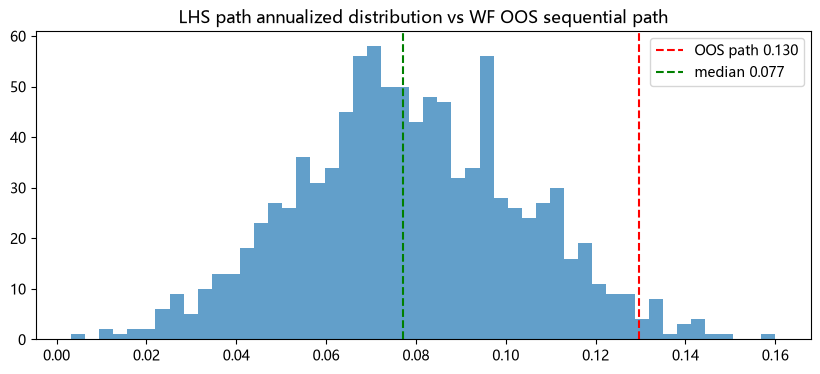

In [14]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [15]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
log_print(diagnose_result, section='OSS DSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1638 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.70%
  ✅ Sharpe 90% CI         : [0.152, 0.835]
  ✅ MDD median / worst-5%  : 20.18% / 28.60%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.4964
  ⚠️ DSR                   : 1.0000  (z=13.19, n_trials=1)


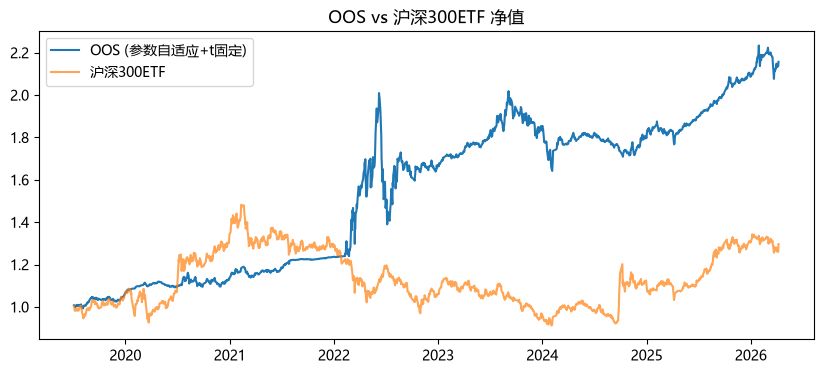

In [16]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [17]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="4.2 A3 vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%       -0.0032       -0.0163 -0.0997   0.5018
50%       0.0350        0.0235  0.1467   0.5140
95%       0.0757        0.0658  0.4120   0.5269
mean      0.0362        0.0248  0.1534   0.5142
